# OCW Dataset EDA
Exploratory analysis of `artifacts/ocw_dataset.parquet` — the clean, deduplicated dataset built by `build_ocw_dataset.py`.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("artifacts/ocw_dataset.parquet")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (549, 18)

Columns: ['doc_id', 'extracted_text', 'label', 'label_source', 'course_id', 'source_url', 'source', 'ingestion_timestamp', 'dataset_version', 'department', 'course_title', 'semester', 'filename', 'char_count', 'word_count', 'file_size_bytes', 'text_extraction_method', 'instructor']

Dtypes:
doc_id                      str
extracted_text              str
label                       str
label_source                str
course_id                   str
source_url                  str
source                      str
ingestion_timestamp         str
dataset_version             str
department                  str
course_title                str
semester                    str
filename                    str
char_count                int64
word_count                int64
file_size_bytes           int64
text_extraction_method      str
instructor                  str
dtype: object


In [46]:
# --- Schema sample ---
df[["doc_id", "label", "label_source", "course_id", "source", "dataset_version", "ingestion_timestamp", "filename"]].head(5)

,doc_id,label,label_source,course_id,source,dataset_version,ingestion_timestamp,filename
0,10847ee2bc4b,Lecture Notes,folder_structure,18.01,mit_ocw,v1.0,2026-04-03T05:32:32Z,dcd410f264f661f8ac1e53ea6df740cc_lec22.pdf
1,ae87f263295e,Lecture Notes,folder_structure,18.01,mit_ocw,v1.0,2026-04-03T05:32:32Z,2a2c56d0665ea6c00add496287b1d41a_lec25.pdf
2,aa2f2e1cbd96,Exam,folder_structure,18.01,mit_ocw,v1.0,2026-04-03T05:32:32Z,7025cfa8c7d4f105856a70f9fdc10db3_prfinal.pdf
3,310860ba5e3f,Other,no_rule_matched,18.01,mit_ocw,v1.0,2026-04-03T05:32:32Z,d37dbf3b71f85754cee509c6f7b8f490_CXKoCMVqM9s.pdf
4,38c10a30f85d,Lecture Notes,folder_structure,18.01,mit_ocw,v1.0,2026-04-03T05:32:32Z,fb8c24f09aba8413984f8ce5961586bd_lec13.pdf


In [55]:
df.head()

,doc_id,extracted_text,label,label_source,course_id,source_url,source,ingestion_timestamp,dataset_version,department,course_title,semester,filename,char_count,word_count,file_size_bytes,text_extraction_method,instructor
0,10847ee2bc4b,MIT OpenCourseWare \nhttp://ocw.mit.edu \n18.0...,Lecture Notes,folder_structure,18.01,https://ocw.mit.edu/courses/18-01-single-varia...,mit_ocw,2026-04-03T05:32:32Z,v1.0,Mathematics,Single Variable Calculus,Fall 2006,dcd410f264f661f8ac1e53ea6df740cc_lec22.pdf,4441,958,1773808,pypdf,David Jerison
1,ae87f263295e,MIT OpenCourseWare \nhttp://ocw.mit.edu \n18.0...,Lecture Notes,folder_structure,18.01,https://ocw.mit.edu/courses/18-01-single-varia...,mit_ocw,2026-04-03T05:32:32Z,v1.0,Mathematics,Single Variable Calculus,Fall 2006,2a2c56d0665ea6c00add496287b1d41a_lec25.pdf,2703,499,607859,pypdf,David Jerison
2,aa2f2e1cbd96,MIT OpenCourseWare \nhttp://ocw.mit.edu\n \n \...,Exam,folder_structure,18.01,https://ocw.mit.edu/courses/18-01-single-varia...,mit_ocw,2026-04-03T05:32:32Z,v1.0,Mathematics,Single Variable Calculus,Fall 2006,7025cfa8c7d4f105856a70f9fdc10db3_prfinal.pdf,4624,942,126598,pypdf,David Jerison
3,310860ba5e3f,MITOCW | ocw-18-01-f07-lec28_300k\nThe followi...,Other,no_rule_matched,18.01,https://ocw.mit.edu/courses/18-01-single-varia...,mit_ocw,2026-04-03T05:32:32Z,v1.0,Mathematics,Single Variable Calculus,Fall 2006,d37dbf3b71f85754cee509c6f7b8f490_CXKoCMVqM9s.pdf,29206,5651,49816,pypdf,David Jerison
4,38c10a30f85d,MIT OpenCourseWare \nhttp://ocw.mit.edu \n18.0...,Lecture Notes,folder_structure,18.01,https://ocw.mit.edu/courses/18-01-single-varia...,mit_ocw,2026-04-03T05:32:32Z,v1.0,Mathematics,Single Variable Calculus,Fall 2006,fb8c24f09aba8413984f8ce5961586bd_lec13.pdf,6837,1500,1224586,pypdf,David Jerison


label
Lecture Notes    186
Other            147
Problem Set       96
Exam              60
Reading           60


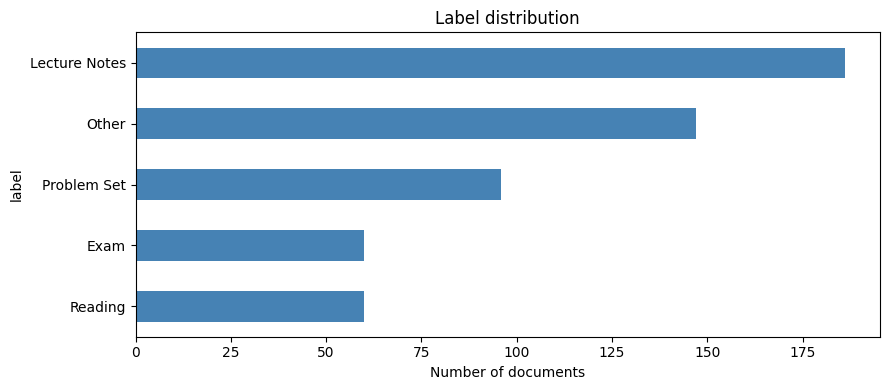

In [47]:
# --- Label distribution ---
label_counts = df["label"].value_counts()
print(label_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
label_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of documents")
ax.set_title("Label distribution")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

course_id
5.111SC    204
6.006      122
18.01      121
6.034       66
6.042J      36


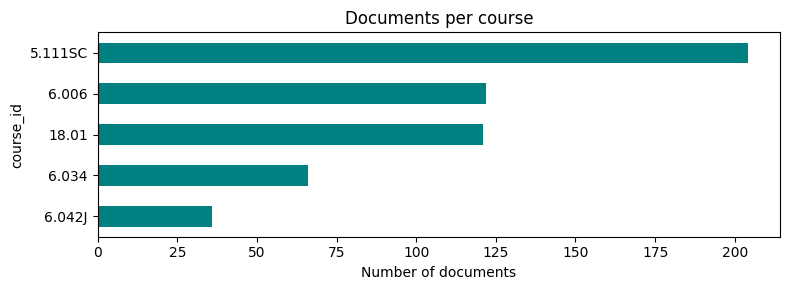

In [48]:
# --- Docs per course ---
course_counts = df["course_id"].value_counts()
print(course_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
course_counts.plot(kind="barh", ax=ax, color="teal")
ax.set_xlabel("Number of documents")
ax.set_title("Documents per course")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

label_source
folder_structure    402
no_rule_matched     147


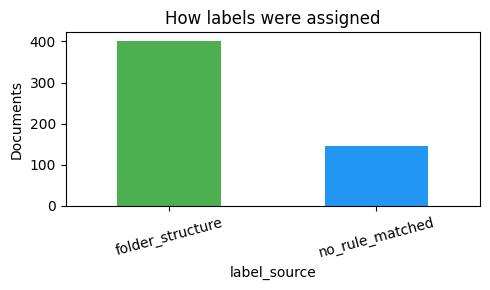

In [49]:
# --- label_source breakdown ---
print(df["label_source"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(5, 3))
df["label_source"].value_counts().plot(kind="bar", ax=ax, color=["#4CAF50", "#2196F3", "#FF9800"])
ax.set_title("How labels were assigned")
ax.set_ylabel("Documents")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()

Text length stats:
count        549.0
mean       18210.0
std        63745.0
min          212.0
25%         3596.0
50%         7830.0
75%        27343.0
max      1457338.0


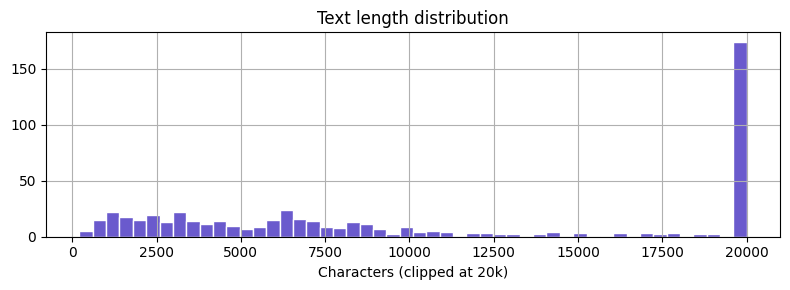

In [50]:
# --- Text length distribution ---
print(f"Text length stats:\n{df['char_count'].describe().round(0).to_string()}")

fig, ax = plt.subplots(figsize=(8, 3))
df["char_count"].clip(upper=20000).hist(bins=50, ax=ax, color="slateblue", edgecolor="white")
ax.set_xlabel("Characters (clipped at 20k)")
ax.set_title("Text length distribution")
plt.tight_layout()
plt.show()

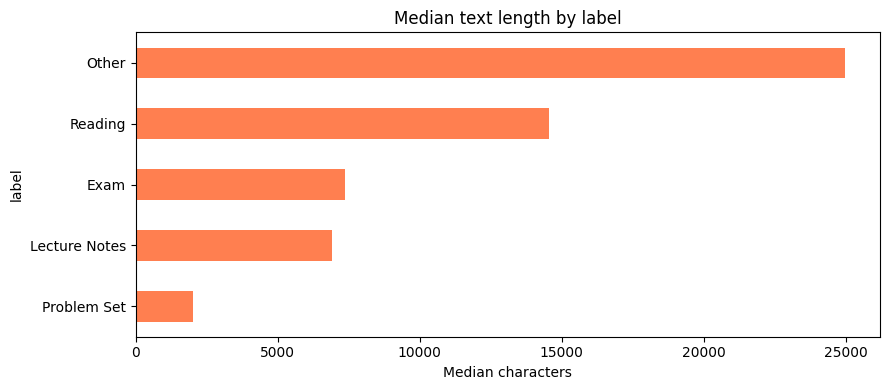

In [51]:
# --- Text length by label ---
df.groupby("label")["char_count"].median().sort_values().plot(
    kind="barh", figsize=(9, 4), color="coral", title="Median text length by label"
)
plt.xlabel("Median characters")
plt.tight_layout()
plt.show()

In [52]:
# --- Sample text per label ---
for label, group in df.groupby("label"):
    row = group.sample(1, random_state=42).iloc[0]
    print(f"{'='*60}")
    print(f"LABEL: {label}")
    print(f"Course: {row['course_id']}  |  File: {row['filename']}")
    print(f"Text preview ({row['char_count']} chars):")
    print(row["extracted_text"][:400].replace("\n", " "))
    print()

LABEL: Exam
Course: 18.01  |  File: 7025cfa8c7d4f105856a70f9fdc10db3_prfinal.pdf
Text preview (4624 chars):
MIT OpenCourseWare  http://ocw.mit.edu       18.01 Single Variable Calculus       For information about citing these materials or our Terms of Use, visit: http://ocw.mit.edu/terms .     Fall 2006  �  � �  �  �  18.01 Practice Final Exam There are 19 problems, totaling 250 points. No books, notes, or calculators. This practice exam should  take 3 hours.  Generally useful trigonometry:  sin2 x = 1 −

LABEL: Lecture Notes
Course: 5.111SC  |  File: baadb16aee67573e5c734c292c249a69_MIT5_111F14_Lec21.pdf
Text preview (6788 chars):
5.111 Lecture Summary #21 Wednesday, October 29, 2014  Reading for Today: Sections 11.7-11.9, 11.11-11.12 (10.7 -10.9, 10.11 – 10.12 in 4th ed.) Reading for Lecture #22: Sections 11.13, 11.18-11.19, 12.1-12.3 (10.13, 10.18-10.19, 11.1- 11.3 in 4th ed.)  Topics: I. Definitions and Relationships between pKw, pH, and pOH II. Strengths of Acids and Bases III. Equ

In [ ]:
# --- What training team gets ---
# Input:  extracted_text (string)
# Output: label (one of the classes below)
print("Label classes (model outputs):")
for i, label in enumerate(sorted(df["label"].unique())):
    print(f"  {i:2d}. {label}")

print(f"\nTotal documents: {len(df)}")
print(f"Courses: {df['course_id'].nunique()}")
print(f"Dataset version: {df['dataset_version'].iloc[0]}")
print(f"Ingested at: {df['ingestion_timestamp'].iloc[0]}")

Label classes (model outputs):
   0. Exam
   1. Lecture Notes
   2. Other
   3. Problem Set
   4. Reading

Total documents: 549
Courses: 5
Dataset version: v1.0
Ingested at: 2026-04-03T05:32:32Z


In [54]:
# --- JSON interface sample (for serving team) ---
import json

sample = df.sample(1, random_state=7).iloc[0]
input_payload  = {"text": sample["extracted_text"][:1000]}
output_payload = {"label": sample["label"]}

print("=== Sample INPUT payload (what serving receives) ===")
print(json.dumps(input_payload, indent=2)[:600])
print("\n=== Sample OUTPUT payload (what model returns) ===")
print(json.dumps(output_payload, indent=2))

=== Sample INPUT payload (what serving receives) ===
{
  "text": "MITOCW | watch?v=XKeAd4xybjM\nThe following content is provided under a Creative Commons license. Your support will help\nMIT OpenCourseWare continue to offer high-quality educational resources for free. To make a\ndonation or to view additional materials from hundreds of MIT courses, visit MIT\nOpenCourseWare at ocw.mit.edu.\nCATHERINE\nDRENNAN:\nSo radioactive decay is kind of a classic example of a first-order process. So we are doing one\nlittle tiny section of the chapter on nuclear chemistry, and we're doing that all today. And so all\nwe're really covering is problems assoc

=== Sample OUTPUT payload (what model returns) ===
{
  "label": "Lecture Notes"
}
